# 2D Scalar Transport

## Import Library

In [16]:
import numpy as np
import matplotlib.pyplot as plt

## Domain Setup

In [17]:
L  = 1
Nx = 200
Ny = 200

dx = L / Nx
dy = L / Ny
print("Grid spacing (dx):", dx, "  (dy):", dy)

x = np.linspace(0, L, Nx, endpoint=False)
y = np.linspace(0, L, Ny, endpoint=False)

# Velocity field (constant, uniform)
u_vel = 1.0
v_vel = 0.5

# Diffusion coefficient
alpha = 0.001

# Combined stability condition (upwind + central diffusion in 2D):
#   CFL_x + CFL_y + 4r ≤ 1
#   dt*(u/dx + v/dy + 4*alpha/dx²) ≤ safety
# Solve for dt directly — works for any grid size
safety = 0.8
dt = safety / (u_vel/dx + v_vel/dy + 4*alpha/dx**2)

CFL_x = u_vel * dt / dx
CFL_y = v_vel * dt / dy
r     = alpha * dt / dx**2
print(f"dt       = {dt:.6f}")
print(f"CFL_x    = {CFL_x:.4f}")
print(f"CFL_y    = {CFL_y:.4f}")
print(f"r        = {r:.4f}")
print(f"Combined = {CFL_x + CFL_y + 4*r:.4f}  (must be ≤ 1)")

nt = 400
T  = nt * dt
print(f"Total simulation time T = {T:.4f}")


Grid spacing (dx): 0.005   (dy): 0.005
dt       = 0.001739
CFL_x    = 0.3478
CFL_y    = 0.1739
r        = 0.0696
Combined = 0.8000  (must be ≤ 1)
Total simulation time T = 0.6957


### INITIAL CONDITION: A 2D Gaussian pulse

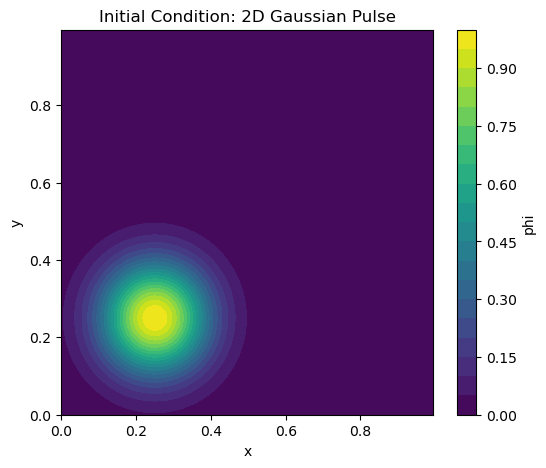

In [18]:
pulse_center = (0.25, 0.25)
pulse_width  = 0.1

X, Y = np.meshgrid(x, y)   # X: (Ny, Nx),  Y: (Ny, Nx)

# phi is the SCALAR FIELD (not u or v — those are velocities!)
phi0 = np.exp(-((X - pulse_center[0])**2 + (Y - pulse_center[1])**2) / (2 * pulse_width**2))

plt.figure(figsize=(6, 5))
plt.contourf(X, Y, phi0, levels=20, cmap='viridis')
plt.colorbar(label='phi')
plt.title('Initial Condition: 2D Gaussian Pulse')
plt.xlabel('x'); plt.ylabel('y')
plt.show()


## Solve - 2D Scalar Transport

In [19]:
def scalar_transport_2d(phi, u_vel, v_vel, alpha, dt, dx, dy):
    """One explicit time step of 2D scalar transport (upwind convection + central diffusion)."""

    # Neighbours of phi — axis=1 for x-shifts, axis=0 for y-shifts
    phi_left  = np.roll(phi,  1, axis=1)  # phi_{i-1, j}
    phi_right = np.roll(phi, -1, axis=1)  # phi_{i+1, j}
    phi_down  = np.roll(phi,  1, axis=0)  # phi_{i, j-1}
    phi_up    = np.roll(phi, -1, axis=0)  # phi_{i, j+1}

    # Upwind convection — velocity is a scalar constant here (uniform flow)
    conv_x = (np.maximum(u_vel, 0) * (phi - phi_left)  +
              np.minimum(u_vel, 0) * (phi_right - phi)) / dx

    conv_y = (np.maximum(v_vel, 0) * (phi - phi_down)  +
              np.minimum(v_vel, 0) * (phi_up - phi))   / dy

    # Central difference diffusion (Laplacian)
    diff_x = alpha * (phi_right - 2*phi + phi_left) / dx**2
    diff_y = alpha * (phi_up    - 2*phi + phi_down) / dy**2

    # Single combined update for the scalar phi
    return phi - dt * (conv_x + conv_y) + dt * (diff_x + diff_y)


# Time loop — pass the CURRENT solution each step
phi = phi0.copy()
phi_history = [phi.copy()]

for n in range(nt):
    phi = scalar_transport_2d(phi, u_vel, v_vel, alpha, dt, dx, dy)
    phi_history.append(phi.copy())

print(f"Done. {nt} steps, T = {T:.4f}")
print(f"Max phi initial = {phi_history[0].max():.4f},  final = {phi_history[-1].max():.4f}")


Done. 400 steps, T = 0.6957
Max phi initial = 1.0000,  final = 0.7560


## Result

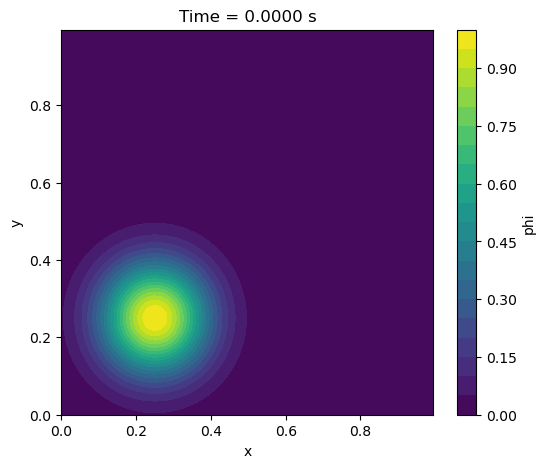

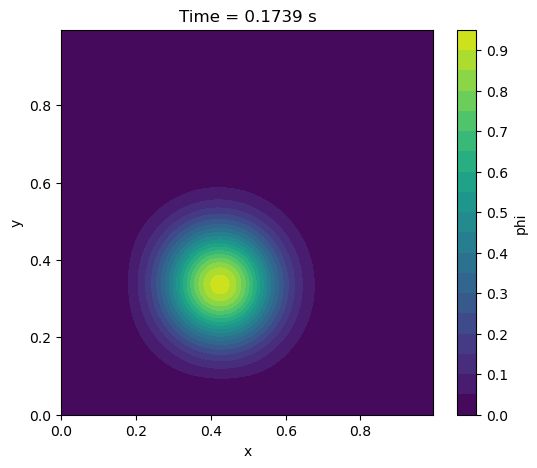

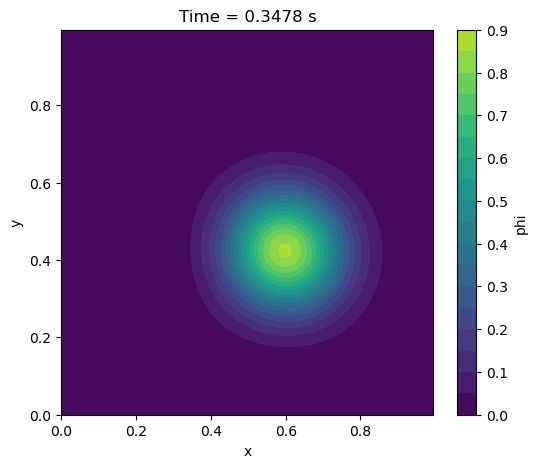

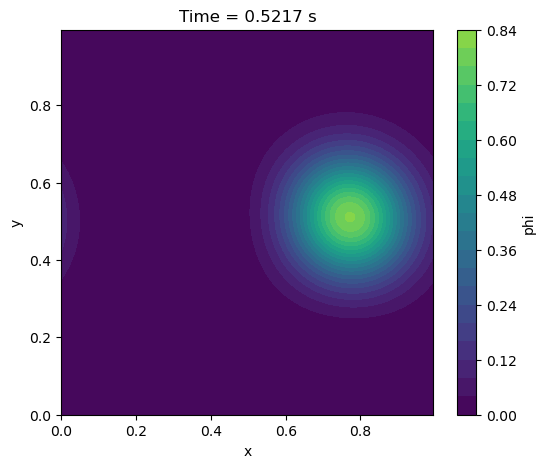

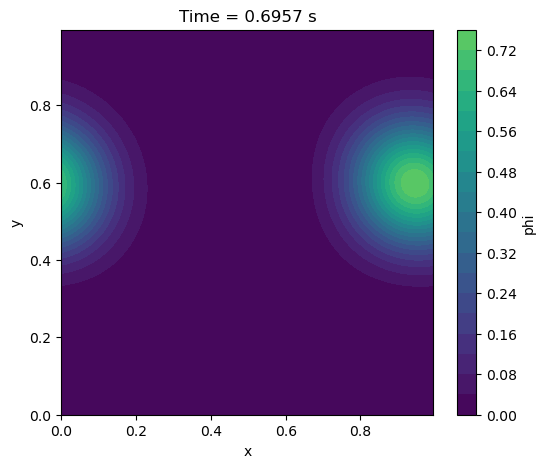

max phi at final time: 0.7560465930729062


In [20]:
snap_indices = [0, nt//4, nt//2, 3*nt//4, nt]
vmin, vmax = 0, phi_history[0].max()

for idx in snap_indices:
    plt.figure(figsize=(6, 5))
    plt.contourf(X, Y, phi_history[idx], levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
    plt.colorbar(label='phi')
    plt.title(f'Time = {idx*dt:.4f} s')
    plt.xlabel('x'); plt.ylabel('y')
    plt.show()

print("max phi at final time:", phi_history[-1].max())